In [81]:
#import necessary libraries
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.compose import ColumnTransformer # for preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder # for scaling and encoding
from sklearn.model_selection import train_test_split # for splitting data

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

from sklearn.model_selection import train_test_split, GridSearchCV # for hyperparameter tuning

import sys
sys.path.append('../src')
from RemoveOutliers import remove_outliers



In [82]:
#load the cleaned data
df_cleaned = pd.read_csv("../data/cleaned_data.csv")

In [83]:
# Define features and target variable
X = df_cleaned.drop('BAD', axis=1)
y = df_cleaned['BAD']

In [84]:
#display the first few rows of the dataframe
X.head()

,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1100,25860.00,39025.00,HomeImp,Other,10.50,0.00,0.00,94.37,1.00,9.00,NaN
1,1300,70053.00,68400.00,HomeImp,Other,7.00,0.00,2.00,121.83,0.00,14.00,NaN
2,1500,13500.00,16700.00,HomeImp,Other,4.00,0.00,0.00,149.47,1.00,10.00,NaN
3,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1700,97800.00,112000.00,HomeImp,Office,3.00,0.00,0.00,93.33,0.00,14.00,NaN


In [85]:
#display the shape of the dataframe
X.shape

(5960, 12)

In [86]:
#separate numerical and categorical variables
num_var = X.select_dtypes(include=['int64', 'float64'])
cat_var = X.select_dtypes(include=['object','category'])

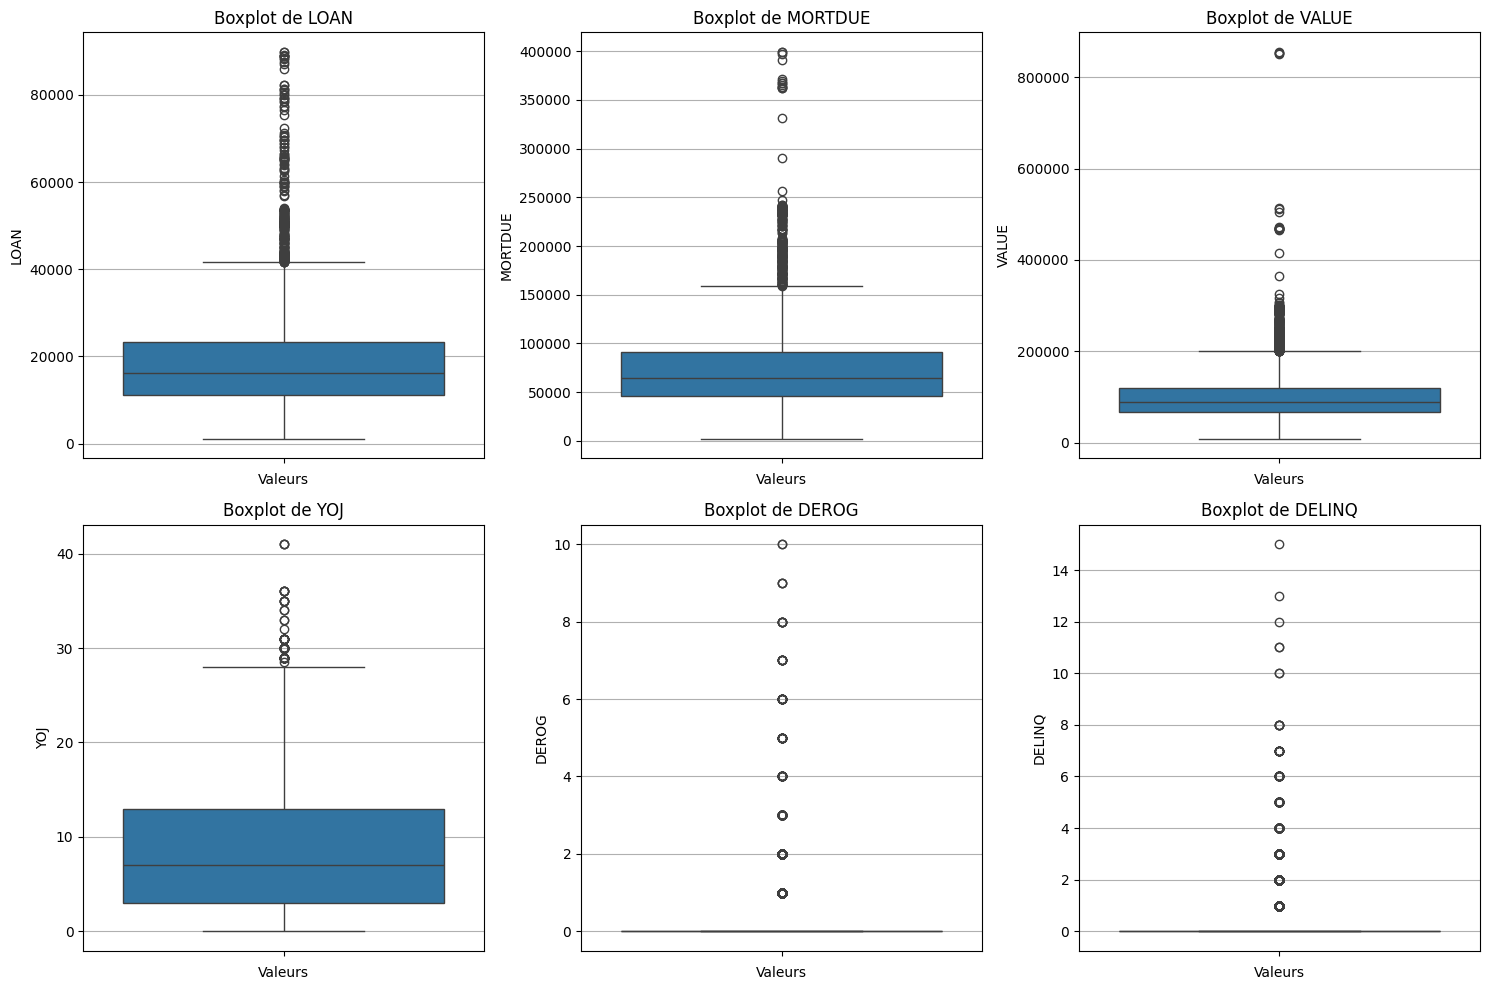

In [87]:
# Boxplot des variables
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, column in zip(axes.flatten(), num_var.columns):
    sns.boxplot(y=X[column], ax=ax) 
    ax.set_title(f"Boxplot de {column}")
    ax.set_xlabel("Valeurs")
    ax.grid(axis='y')

plt.tight_layout()
plt.show()

In [88]:
#df_cleaned = remove_outliers(df_cleaned, num_var.columns)

In [89]:
X.shape

(5960, 12)

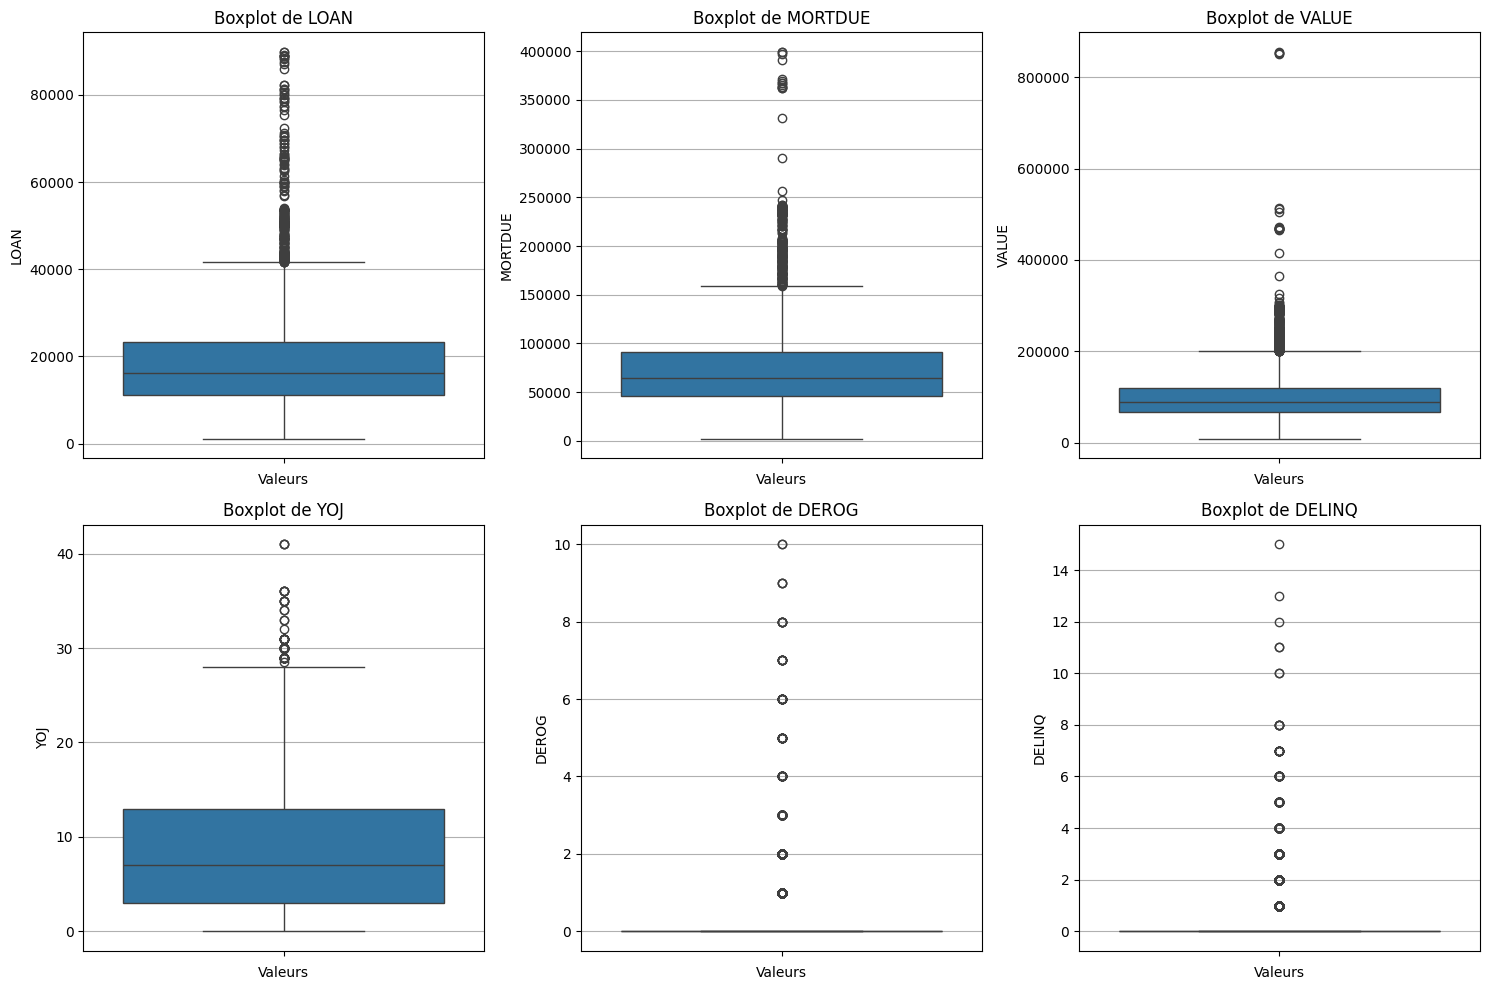

In [90]:
# Boxplot des variables
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, column in zip(axes.flatten(), num_var.columns):
    sns.boxplot(y=df_cleaned[column], ax=ax) 
    ax.set_title(f"Boxplot de {column}")
    ax.set_xlabel("Valeurs")
    ax.grid(axis='y')

plt.tight_layout()
plt.show()

---
Feature Engineering
---

In [91]:
#display the first few rows of the dataframe after feature engineering
X.head()

,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1100,25860.00,39025.00,HomeImp,Other,10.50,0.00,0.00,94.37,1.00,9.00,NaN
1,1300,70053.00,68400.00,HomeImp,Other,7.00,0.00,2.00,121.83,0.00,14.00,NaN
2,1500,13500.00,16700.00,HomeImp,Other,4.00,0.00,0.00,149.47,1.00,10.00,NaN
3,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1700,97800.00,112000.00,HomeImp,Office,3.00,0.00,0.00,93.33,0.00,14.00,NaN


---
Selected the potential model candidate
---

**LAZYPREDICT** 

In [92]:
from lazypredict.Supervised import LazyClassifier
from sklearn.metrics import roc_auc_score

In [ ]:
# Diviser les données
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Utiliser LazyClassifier pour entraîner plusieurs modèles
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=roc_auc_score)
models_par_defaut, predictions = clf.fit(X_train, X_test, y_train, y_test)
print(models_par_defaut.columns)

# Afficher les résultats de tous les modèles
columns_to_keep = ['F1 Score', 'roc_auc_score', 'Time Taken']
filtered_models_par_defaut = models_par_defaut[columns_to_keep]
display(filtered_models_par_defaut)


  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Number of positive: 924, number of negative: 3844
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000261 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1454
[LightGBM] [Info] Number of data points in the train set: 4768, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.193792 -> initscore=-1.425557
[LightGBM] [Info] Start training from score -1.425557
Index(['Accuracy', 'Balanced Accuracy', 'ROC AUC', 'F1 Score', 'recall_score',
       'Time Taken'],
      dtype='object')


,F1 Score,recall_score,Time Taken
Model,,,
ExtraTreesClassifier,0.94,0.76,0.38
XGBClassifier,0.93,0.78,0.12
LGBMClassifier,0.93,0.77,0.12
LabelPropagation,0.93,0.75,0.73
LabelSpreading,0.93,0.75,1.27
RandomForestClassifier,0.92,0.71,0.67
ExtraTreeClassifier,0.88,0.67,0.02
BaggingClassifier,0.89,0.64,0.23
DecisionTreeClassifier,0.86,0.61,0.05


* **Top Performance** : 
Les modèles de type Boosting (**LGBMClassifier** et **XGBClassifier**) dominent le classement avec un **ROC AUC de 0.79/0.80**.

In [ ]:
#save the preprocessed data
#df_cleaned.to_csv('../data/preprocessed_data.csv', index=False)